# LSTM Code Change
#### October 9, 2025

#### Original Code:

                     temp
datetime                 
2024-10-09 00:00:00  20.0
2024-10-09 01:00:00  19.2
2024-10-09 02:00:00  18.5
2024-10-09 03:00:00  17.9
2024-10-09 04:00:00  17.3                      temp
datetime                 
2025-10-09 19:00:00  30.4
2025-10-09 20:00:00  29.4
2025-10-09 21:00:00  28.4
2025-10-09 22:00:00  27.5
2025-10-09 23:00:00  26.8
Shapes: (6892, 168, 1) (6892, 1)
Epoch 1/5


C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - loss: 0.0425 - val_loss: 0.0050
Epoch 2/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - loss: 0.0064 - val_loss: 0.0012
Epoch 3/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.0033 - val_loss: 0.0015
Epoch 4/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 5/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - loss: 0.0022 - val_loss: 0.0024
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
Test RMSE: 2.2776216787032957


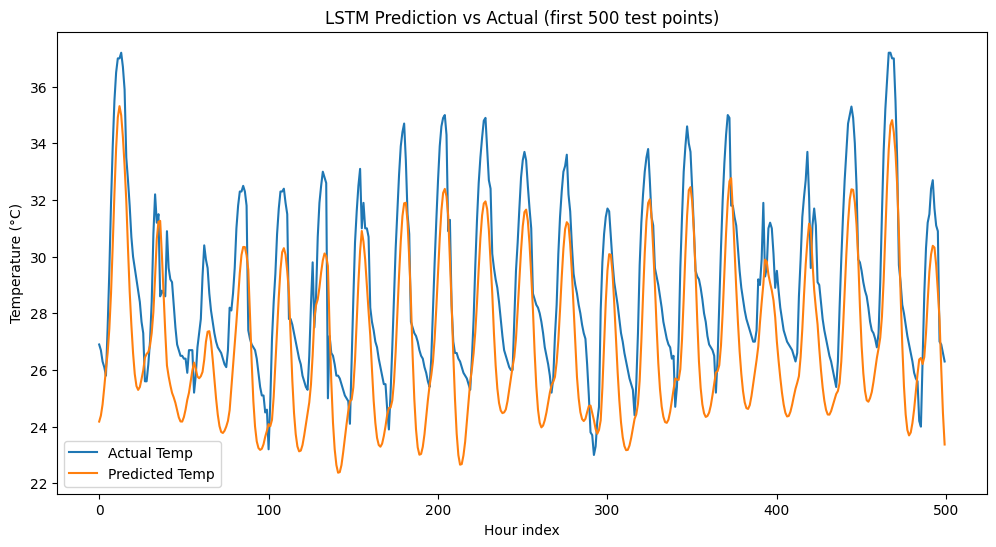

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

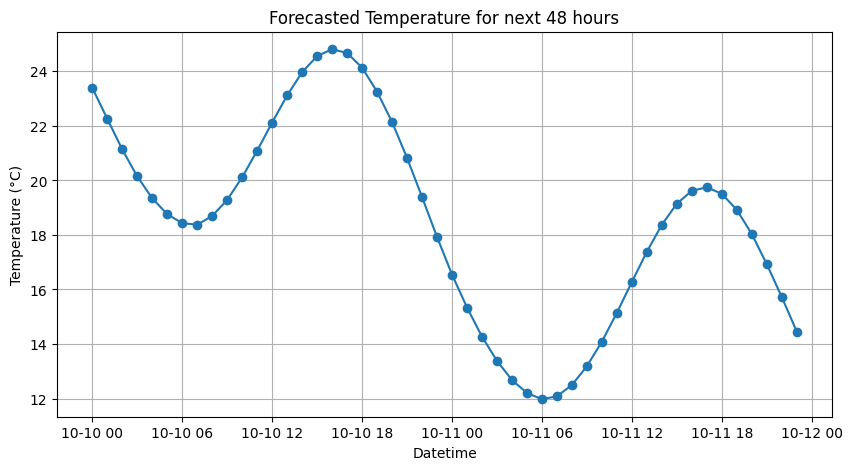

                     pred_temp
2025-10-10 00:00:00  23.397778
2025-10-10 01:00:00  22.260359
2025-10-10 02:00:00  21.136530
2025-10-10 03:00:00  20.145428
2025-10-10 04:00:00  19.344700
2025-10-10 05:00:00  18.761772
2025-10-10 06:00:00  18.431894
2025-10-10 07:00:00  18.375933
2025-10-10 08:00:00  18.696062
2025-10-10 09:00:00  19.283115


In [29]:
# Importing Libraries
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from datetime import datetime, timedelta
import time

def fetch_weather_data(lat, lon, start_date, end_date, timezone="auto"):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
    "latitude": lat,
    "longitude": lon,
    "hourly": "temperature_2m",
    "start_date": start_date,
    "end_date": end_date,
    "timezone": timezone, # ensures times are local
    # optionally include past days in forecast API
    #"past_days": 30
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    j = resp.json()
    # The JSON returns fields “hourly” → “time” and “temperature_2m”
    times = j["hourly"]["time"]
    temps = j["hourly"]["temperature_2m"]
    # Convert to DataFrame
    df = pd.DataFrame({"datetime": times, "temp": temps})
    # Parse datetime
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime")
    return df

# Example: Use coordinates for Houston, TX (approx)
latitude = 29.7604
longitude = -95.3698

# Choose period for training (e.g. past 1 year)
end = datetime.today().date()
start = end - timedelta(days=365)

df_weather = fetch_weather_data(latitude, longitude, start_date=start.isoformat(), end_date=end.isoformat())
print(df_weather.head(), df_weather.tail())

def create_sequences(dataset, seq_length):
    """Given a 1D array (or 2D with single feature), produce (X, y) sequences."""
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i : i + seq_length])
        y.append(dataset[i + seq_length])
    return np.array(X), np.array(y)

# Extract temperature values and scale
data = df_weather["temp"].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)
seq_length = 24 * 7 # use past one week (hourly) to predict next hour
X, y = create_sequences(data_scaled, seq_length)

# Split into train and test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape for LSTM: (samples, timesteps, feature
print("Shapes:", X_train.shape, y_train.shape)

# 3. Build & Train LSTM Model
model = Sequential([
LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
Dropout(0.2),
LSTM(64, return_sequences=False),
Dropout(0.2),
Dense(32, activation="relu"),
Dense(1)
])
model.compile(optimizer="adam", loss="mse")
history = model.fit(
X_train, y_train,
epochs=5,
batch_size=32,
validation_data=(X_test, y_test),
verbose=1
)

# ## 4. Evaluate & Visualize Predictions
# Predict
y_pred = model.predict(X_test)
# Inverse scale
y_pred_orig = scaler.inverse_transform(y_pred)
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))
# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
print("Test RMSE:", rmse)
# Plot predicted vs actual (some window)
plt.figure(figsize=(12,6))
plt.plot(y_test_orig[:500], label="Actual Temp")
plt.plot(y_pred_orig[:500], label="Predicted Temp")
plt.xlabel("Hour index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("LSTM Prediction vs Actual (first 500 test points)")
plt.show()

## 5. Forecast Future Temperature with the Model
def forecast_next_hours(model, last_seq, n_hours):
    """
    last_seq: array shape (seq_length, 1) in scaled space
    Returns a list of predicted scaled values
    """
    seq = last_seq.copy()
    preds = []
    for _ in range(n_hours):
        x = seq.reshape((1, seq_length, 1))
        yhat = model.predict(x)[0][0]
        preds.append(yhat)
        # Slide window
        seq = np.vstack([seq[1:], [[yhat]]])
    return preds

# Use last available part of data
last_sequence = data_scaled[-seq_length:]
n_future = 24 * 2 # e.g. forecast next 2 days (48 hours)
preds_scaled = forecast_next_hours(model, last_sequence, n_future)
preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1))
# Build a datetime index for future
last_dt = df_weather.index[-1]
future_idx = [last_dt + timedelta(hours=i+1) for i in range(n_future)]
df_future = pd.DataFrame({"pred_temp": preds.flatten()}, index=future_idx)
# Plot forecast
plt.figure(figsize=(10,5))
plt.plot(df_future["pred_temp"], marker="o")
plt.title(f"Forecasted Temperature for next {n_future} hours")
plt.xlabel("Datetime")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()
print(df_future.head(10))

#### Improvements implemented:
a. Allowed multiple sequence lengths (24h, 3 days, 1 week)  
b. Added multi-layer (stacked) LSTM  
c. Used additional features (humidity, wind speed)  
d. Longer training epochs, early stopping, learning rate schedules  
e. Compared RMSE across sequence lengths and chose best  
f. Added L2 regularization and increased Dropout

In [1]:
# Importing Libraries
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from datetime import datetime, timedelta

# 1. Loading the dataset. Initializing the fetch_weather_data Function:
def fetch_weather_data(lat, lon, start_date, end_date, timezone="auto"):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        # Added more hourly features for multi-feature input
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m",
        "start_date": start_date,
        "end_date": end_date,
        "timezone": timezone
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()
    j = resp.json()

    # Convert JSON into DataFrame with all features
    df = pd.DataFrame({
        "datetime": j["hourly"]["time"],
        "temp": j["hourly"]["temperature_2m"],
        "humidity": j["hourly"]["relative_humidity_2m"],
        "wind": j["hourly"]["wind_speed_10m"]
    })
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime")
    return df

# Example: coordinates for Houston, TX
latitude = 29.7604
longitude = -95.3698

# Choose period for training (past 1 year)
end = datetime.today().date()
start = end - timedelta(days=365)
df_weather = fetch_weather_data(latitude, longitude, start.isoformat(), end.isoformat())
print("Sample data:\n", df_weather.head())

# 2. CREATE SEQUENCES FUNCTION (unchanged):
def create_sequences(dataset, seq_length):
    """Given a multivariate array, produce (X, y) sequences."""
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i : i + seq_length])
        y.append(dataset[i + seq_length, 0])  # predict next temperature
    return np.array(X), np.array(y)

# 3. SCALE DATA (now includes all features):
data = df_weather[["temp", "humidity", "wind"]].values
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

Sample data:
                      temp  humidity  wind
datetime                                 
2024-10-12 00:00:00  20.7        88   6.9
2024-10-12 01:00:00  19.9        93   6.5
2024-10-12 02:00:00  19.4        94   6.3
2024-10-12 03:00:00  18.7        95   7.7
2024-10-12 04:00:00  18.3        95   8.1


In [4]:
# 3. Build & Train LSTM Model
seq_lengths = [24, 72, 168]  # 1 day, 3 days, 1 week of hourly data
results, histories = {}, {}

for seq in seq_lengths:
    X, y = create_sequences(data_scaled, seq)
    split = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(seq, X_train.shape[2]), kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        LSTM(64, kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=20, batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(X_test, verbose=0)
    y_test_inv = scaler.inverse_transform(np.hstack([y_test.reshape(-1,1), np.zeros((len(y_test),2))]))[:,0]
    y_pred_inv = scaler.inverse_transform(np.hstack([y_pred, np.zeros((len(y_pred),2))]))[:,0]

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    results[seq] = {'rmse': rmse, 'y_test': y_test_inv, 'y_pred': y_pred_inv}
    histories[seq] = history
    print(f"RMSE ({seq}): {rmse:.3f}")

C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE (24): 0.899


C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE (72): 0.855


C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE (168): 0.951


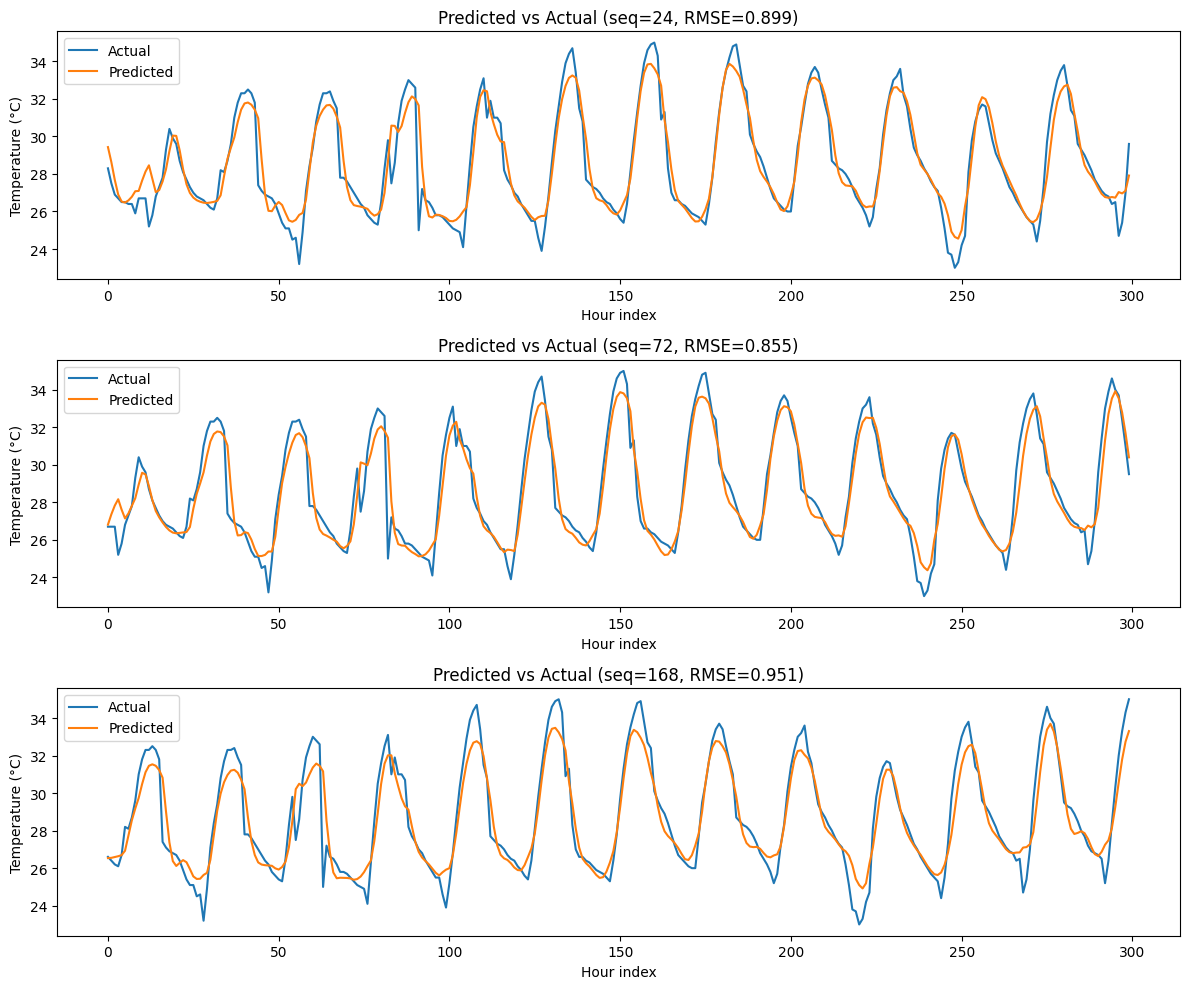

In [13]:
# 4. EVALUATE & VISUALIZE PREDICTIONS
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes = axes.ravel()

# 1. Plot predicted vs actual for each sequence length
for i, seq in enumerate(seq_lengths):
    axes[i].plot(results[seq]['y_test'][:300], label='Actual')
    axes[i].plot(results[seq]['y_pred'][:300], label='Predicted')
    axes[i].set_title(f"Predicted vs Actual (seq={seq}, RMSE={results[seq]['rmse']:.3f})")
    axes[i].set_xlabel("Hour index")
    axes[i].set_ylabel("Temperature (°C)")
    axes[i].legend()

# 2. RMSE comparison
# axes[-1].bar([str(s) for s in seq_lengths], [results[s]['rmse'] for s in seq_lengths], color='skyblue')
# axes[-1].set_title("RMSE Comparison Across Sequence Lengths")
# axes[-1].set_xlabel("Sequence Length (hours)")
# axes[-1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()


Summary of RMSEs per sequence length: {24: {'rmse': 0.8994016329342488, 'y_test': array([28.3, 27.5, 26.9, ..., 25.5, 24.7, 24.1]), 'y_pred': array([29.43194505, 28.62811891, 27.68622602, ..., 26.75486892,
       25.51191574, 24.35734367])}, 72: {'rmse': 0.8551610952784365, 'y_test': array([26.7, 26.7, 26.7, ..., 25.5, 24.7, 24.1]), 'y_pred': array([26.80862458, 27.36138998, 27.82552644, ..., 26.38149556,
       25.03713886, 23.97809935])}, 168: {'rmse': 0.9512939650958466, 'y_test': array([26.6, 26.4, 26.2, ..., 25.5, 24.7, 24.1]), 'y_pred': array([26.53694663, 26.54947062, 26.59036357, ..., 26.42743061,
       25.26138923, 24.2348851 ])}}
✅ Best performing sequence length: 72 hours


C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - loss: 0.0485
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - loss: 0.0115
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - loss: 0.0074
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.0056
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - loss: 0.0042
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0034
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - loss: 0.0028
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - loss: 0.0023
Epoch 9/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - loss: 0.0020
Epoch 10/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0018


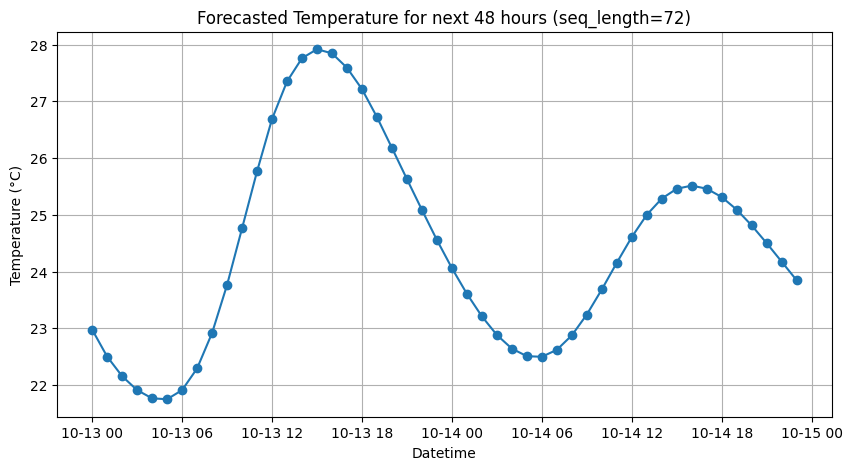

                     pred_temp
2025-10-13 00:00:00  22.977940
2025-10-13 01:00:00  22.502615
2025-10-13 02:00:00  22.156713
2025-10-13 03:00:00  21.911361
2025-10-13 04:00:00  21.766308
2025-10-13 05:00:00  21.750689
2025-10-13 06:00:00  21.911019
2025-10-13 07:00:00  22.292098
2025-10-13 08:00:00  22.916212
2025-10-13 09:00:00  23.763068


In [11]:
# 5. FORECAST FUTURE TEMPERATURE WITH THE MODEL
best_seq = min(results, key=lambda k: results[k]['rmse'])
print("\nSummary of RMSEs per sequence length:", results)
print(f"✅ Best performing sequence length: {best_seq} hours")

# Forecasting future temperatures with best model
# Re-train model with best_seq_length on full dataset
seq_length = best_seq
X, y = create_sequences(data_scaled, seq_length)
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_length, X.shape[2]), kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=10, batch_size=32, verbose=1)

def forecast_next_hours(model, last_seq, n_hours):
    """Iteratively forecast next n_hours using the trained model."""
    seq = last_seq.copy()
    preds = []
    for _ in range(n_hours):
        x = seq.reshape((1, seq_length, seq.shape[1]))
        yhat = model.predict(x, verbose=0)[0][0]
        preds.append(yhat)
        seq = np.vstack([seq[1:], [np.append(yhat, seq[-1,1:])]])  # shift and reuse other features
    return preds

# Forecast next 48 hours
last_seq = data_scaled[-seq_length:]
n_future = 48
preds_scaled = forecast_next_hours(model, last_seq, n_future)
preds = scaler.inverse_transform(np.hstack([np.array(preds_scaled).reshape(-1,1),
                                            np.zeros((n_future,2))]))[:,0]

# Build datetime index
last_dt = df_weather.index[-1]
future_idx = [last_dt + timedelta(hours=i+1) for i in range(n_future)]
df_future = pd.DataFrame({"pred_temp": preds}, index=future_idx)

# Plot forecast
plt.figure(figsize=(10,5))
plt.plot(df_future["pred_temp"], marker="o")
plt.title(f"Forecasted Temperature for next {n_future} hours (seq_length={best_seq})")
plt.xlabel("Datetime")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

print(df_future.head(10))